# Multiple Q-learning on Dynamic Treatement Regimes : a cancer simulation case study

In [11]:
# ----------------------------------------------------------
# Librairies
# ----------------------------------------------------------

import numpy as np
import pandas as pd
import sys, time, random
import matplotlib.pyplot as plt
import os
from matplotlib.lines import Line2D
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Repro
# ----------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ----------------------------------------------------------
# Imports
# ----------------------------------------------------------
sys.path.append("scripts")

import DTR_Cancer_DataGeneration as gen
from DTR_Cancer_DataGeneration import (
    generate_dataset,
    calculate_rewards,
    create_data_stage_frames,
    constant_dose_regimes,
    generate_patient_trajectory
)

from NearEquivalentQlearning import NearEquivalentQlearning, classicalQlearning

In [12]:
# ----------------------------------------------------------
# Config 
# ----------------------------------------------------------
N_train = 500
N_traj  = 5000

T_final = 6
number_of_decision = 5  # stages 0..5

epsilon_selection = 0.1
possibles_treatments = np.round(np.arange(0.1, 1.1, 0.1), 1)

# ----------------------------------------------------------
# Helpers
# ----------------------------------------------------------
def shift_rewards_positive(rew: pd.DataFrame, eps: float = 1.0) -> pd.DataFrame:
    out = rew.copy()
    for col in out.columns:
        m = out[col].min()
        if pd.isna(m):
            continue
        if m <= 0:
            out[col] = out[col] + (abs(m) + eps)
    return out

def stagewise_standardize_numeric_only(data_stages_raw: dict, max_stage: int):
    data_stages_scaled = {}
    stage_scalers = {}
    for k in range(max_stage + 1):
        key = f"Data_Stage_{k}"
        Xk = data_stages_raw[key].copy()
        num_cols = Xk.select_dtypes(include=[np.number]).columns.tolist()
        scaler = StandardScaler()
        Xk[num_cols] = scaler.fit_transform(Xk[num_cols])
        data_stages_scaled[key] = Xk
        stage_scalers[k] = scaler
    return data_stages_scaled, stage_scalers

def get_stage_model(models_by_stage, stage: int, policy_index: int):
    """
    Stage 0..4 : list[SVR]
    Stage 5    : single SVR
    """
    m = models_by_stage[stage]
    if isinstance(m, list):
        idx = min(policy_index, len(m) - 1)
        return m[idx]
    return m

def build_policy_Qs_from_models(models_by_stage, policy_index: int):
    return (
        get_stage_model(models_by_stage, 0, policy_index),
        get_stage_model(models_by_stage, 1, policy_index),
        get_stage_model(models_by_stage, 2, policy_index),
        get_stage_model(models_by_stage, 3, policy_index),
        get_stage_model(models_by_stage, 4, policy_index),
        get_stage_model(models_by_stage, 5, policy_index),
    )

In [13]:
# ----------------------------------------------------------
# Data + rewards
# ----------------------------------------------------------
Data_raw, Remission_Informations, Dead_Informations = generate_dataset(N=N_train)

Rewards_Zhao = calculate_rewards(
    Data_raw,
    Remission_Informations,
    Dead_Informations,
    T_final=T_final
)
Rewards_Zhao = shift_rewards_positive(Rewards_Zhao, eps=1.0)

for k in range(number_of_decision + 1):
    assert f"Reward_{k}" in Rewards_Zhao.columns

# ----------------------------------------------------------
# Stage datasets 0..5
# ----------------------------------------------------------
data_stages_raw = create_data_stage_frames(Data_raw, number_of_decision)
for k in range(number_of_decision + 1):
    assert f"Data_Stage_{k}" in data_stages_raw

data_stages, stage_scalers = stagewise_standardize_numeric_only(
    data_stages_raw, number_of_decision
)
gen.STAGE_SCALERS = stage_scalers

# ----------------------------------------------------------
# Train classical (opt)
# ----------------------------------------------------------
Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt = classicalQlearning(
    number_of_decision,
    data_stages,
    Rewards_Zhao,
    possibles_treatments
)

# ----------------------------------------------------------
# Train near-equivalent models
# ----------------------------------------------------------
models_by_stage = NearEquivalentQlearning(
    number_of_decision,
    data_stages,
    Rewards_Zhao,
    possibles_treatments,
    epsilon_selection=epsilon_selection
)

# Number of NEQ policies = number of models at stage 4
K = len(models_by_stage[number_of_decision - 1])
#print(f"Near-equivalent policies available: K = {K}")


In [14]:
# ----------------------------------------------------------
# Rollout (online means)
# ----------------------------------------------------------
Y0_test = np.random.uniform(0, 2)
X0_test = np.random.uniform(0, 2)
ty, tx = generate_patient_trajectory(
    Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt,
    Y0_test, X0_test, possibles_treatments
)
n_points = len(ty)
time_grid = np.arange(n_points)

sum_XY = {"opt": np.zeros(n_points)}
for m in range(K):
    sum_XY[f"M{m}"] = np.zeros(n_points)

sum_const = {d: np.zeros(n_points) for d in possibles_treatments}

for _ in range(N_traj):
    Y0 = np.random.uniform(0, 2)
    X0 = np.random.uniform(0, 2)

    # classical opt
    y_opt, x_opt = generate_patient_trajectory(
        Q0_opt, Q1_opt, Q2_opt, Q3_opt, Q4_opt, Q5_opt,
        Y0, X0, possibles_treatments
    )
    sum_XY["opt"] += (np.asarray(y_opt) + np.asarray(x_opt))

    # near-equivalent policies
    for m in range(K):
        Qs = build_policy_Qs_from_models(models_by_stage, m)
        y_m, x_m = generate_patient_trajectory(
            *Qs, Y0, X0, possibles_treatments
        )
        sum_XY[f"M{m}"] += (np.asarray(y_m) + np.asarray(x_m))

    # constant-dose
    for d in possibles_treatments:
        ty_c, tx_c = constant_dose_regimes(d, Y0, X0, T_final)
        sum_const[d] += (np.asarray(ty_c) + np.asarray(tx_c))

mean_XY = {k: v / N_traj for k, v in sum_XY.items()}
mean_const = {d: v / N_traj for d, v in sum_const.items()}

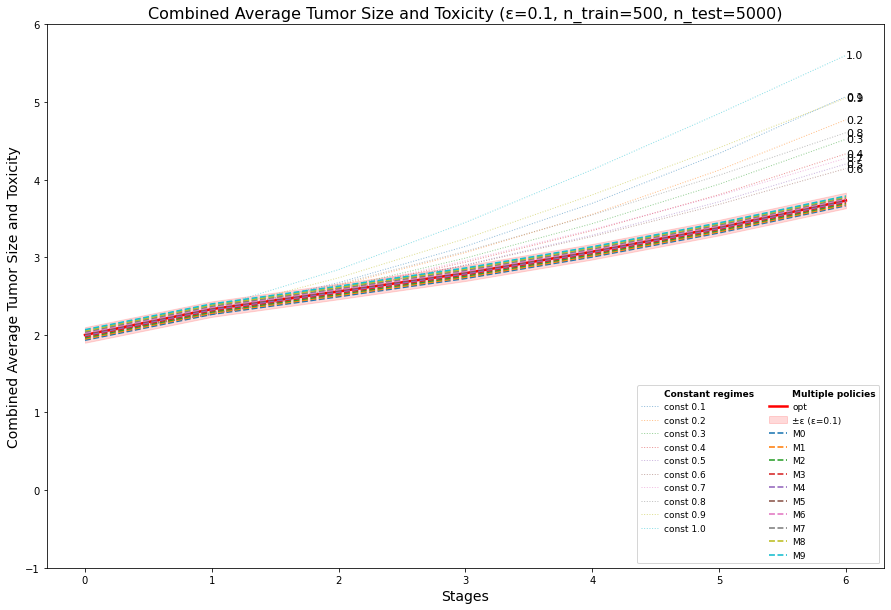

In [15]:
# ==========================================================
# PLOT: opt + ribbon + M0..Mk (with tiny vertical offsets)
#       + constant-dose regimes (unchanged, labeled)
# ==========================================================
fig, ax = plt.subplots(figsize=(15, 10))

# ----------------------------------------------------------
# 1) Constant-dose regimes (unchanged, labeled at line end)
# ----------------------------------------------------------
for dose in possibles_treatments:
    values = mean_const[dose]
    ax.plot(
        time_grid,
        values,
        ':',
        alpha=0.5,
        linewidth=1,
        label=f"const {dose:.1f}",
        zorder=3   # above ribbon
    )
    ax.text(
        time_grid[-1],
        values[-1],
        f"{dose:.1f}",
        fontsize=11,
        verticalalignment='center'
    )

# ----------------------------------------------------------
# 2) Model-based trajectories: opt + M0.. with visual offsets
# ----------------------------------------------------------
eps_display = 0.015  # PURELY VISUAL separation for M curves

# opt first (no offset)
opt_values = mean_XY["opt"]
ax.plot(
    time_grid,
    opt_values,
    'r-',
    linewidth=2.5,
    label="opt",
    zorder=4
)

# ribbon around opt: ± epsilon_selection (draw BEHIND)
ax.fill_between(
    time_grid,
    opt_values - epsilon_selection,
    opt_values + epsilon_selection,
    color='red',
    alpha=0.15,  # a bit lighter
    label=f"±ε (ε={epsilon_selection})",
    zorder=1
)

# M policies (keep them in legend, separate visually with tiny offsets)
for m in range(K):
    lab = f"M{m}"
    values = mean_XY[lab]

    delta = (m - (K - 1) / 2) * eps_display
    values_disp = values + delta

    ax.plot(
        time_grid,
        values_disp,
        '--',
        linewidth=1.6,
        label=lab,
        zorder=4
    )

# ----------------------------------------------------------
# 3) Axes, title
# ----------------------------------------------------------
ax.set_ylim([-1, 6])

ax.set_xlabel("Stages", fontsize=14)
ax.set_ylabel("Combined Average Tumor Size and Toxicity", fontsize=14)

title = (
    f"Combined Average Tumor Size and Toxicity "
    f"(ε={epsilon_selection}, n_train={N_train}, n_test={N_traj})"
)
ax.set_title(title, fontsize=16)

# ----------------------------------------------------------
# Legend (2 columns, constant vs policies)
# ----------------------------------------------------------
handles, labels = ax.get_legend_handles_labels()

const_h, const_l = [], []
model_h, model_l = [], []

for h, lab in zip(handles, labels):
    if lab.startswith("const"):
        const_h.append(h);  const_l.append(lab)
    else:
        model_h.append(h);  model_l.append(lab)

h_title_const = Line2D([], [], linestyle='None', label='Constant regimes')
h_title_model = Line2D([], [], linestyle='None', label='Multiple policies')
h_blank = Line2D([], [], linestyle='None', label='')

left_h  = [h_title_const] + const_h
left_l  = ['Constant regimes'] + const_l

right_h = [h_title_model] + model_h
right_l = ['Multiple policies'] + model_l

n_rows = max(len(left_h), len(right_h))
left_h  += [h_blank] * (n_rows - len(left_h))
left_l  += ['']      * (n_rows - len(left_l))
right_h += [h_blank] * (n_rows - len(right_h))
right_l += ['']      * (n_rows - len(right_l))

final_h = left_h + right_h
final_l = left_l + right_l

legend = ax.legend(
    final_h, final_l,
    ncol=2,
    loc='lower right',
    fontsize=9,
    frameon=True,
    handlelength=2.0,
    columnspacing=1.6,
    handletextpad=0.6,
)

for t in legend.get_texts():
    if t.get_text() in ("Constant regimes", "Multiple policies"):
        t.set_weight("bold")

# ----------------------------------------------------------
# 4) Save figure and display
# ----------------------------------------------------------
outname = (
    f"results/combined_average_tumor_size_and_toxicity_"
    f"epsilon{epsilon_selection:.2f}_"
    f"nTrain{N_train}_nTest{N_traj}.png"
)

os.makedirs("results", exist_ok=True)

fig.savefig(outname, dpi=300, bbox_inches="tight")

plt.show()